In [1]:
# ================= PORT NA KONWENCJE ARTYKULU (06.09.2026) =================
# Ten notebook jest PORTEM 20260903b.ipynb. Analiza, generatory surogatow, reguly
# odczytu i wykresy sa NIETKNIETE - zmienila sie WYLACZNIE konwencja
# binowania (komorka ze statystyka liczy teraz przez ../statystyka.py w
# konwencji kodu zespolu) oraz nazwy plikow: wejsciowe finetune_* -> credo_*,
# wyjsciowe dostaly przedrostek credo_, zeby nic ze starych wynikow nie
# zostalo nadpisane. Powod i walidacja: dziennik 20260905.txt pkt 13a-13g
# oraz 20260906a.ipynb.
# ==========================================================================

# 03.09.2026 - 20260903b.ipynb: SKAD BIORA SIE GLEBOKIE MINIMA TAM, GDZIE
# Z KONSTRUKCJI NIE MA SYGNALU.
#
# JEDEN watek (konwencja repo: jeden watek = jeden notebook).
#
# PUNKT WYJSCIA. 02.09 (notebook c) wyszla rzecz, ktorej nie umiemy wyjasnic i
# ktora dziennik zapisal jako punkt otwarty w brzmieniu: "dopoki nie wiadomo,
# co to powoduje, kazda liczba dotyczaca ery 1968 w calym repo jest podejrzana".
# Chodzi o to, ze katalog o tempie CALKOWICIE PLASKIM - bez trendu, bez skokow,
# bez zadnej struktury - produkuje minimum przy 1968 w 39 realizacjach na 50, a
# 23 z 44 wszystkich jego minimow leza w latach 1965-1968, czyli na samym
# poczatku zakresu skanu. Era 1968 daje w katalogu prawdziwym NAJGLEBSZE
# minimum w calej analizie (9,72) i jest jedna z pieciu dat wypisanych w
# sekcji 4 artykulu.
#
# PYTANIE: dlaczego statystyka daje glebokie minima na katalogu, w ktorym z
# konstrukcji nie ma zadnego sygnalu.
#
# DWIE HIPOTEZY, obie sprawdzane w tym notebooku, obie tanie:
#
#  H1 - EFEKT BRZEGU ZAKRESU SKANU. Minima ida za poczatkiem (i koncem) siatki
#       t0, a nie za kalendarzem. Test: ta sama krzywa, ale minima wykrywane na
#       piecu roznych PODZAKRESACH siatki (pelny, z poczatkiem przesunietym o
#       3, 6 i 9 lat, oraz z koncem obcietym o 5 lat). Jesli rozklad odleglosci
#       minimum OD POCZATKU ZAKRESU jest taki sam we wszystkich wariantach,
#       jest to czysty artefakt brzegowy. Jesli minima zostaja przypiete do
#       tych samych DAT KALENDARZOWYCH, jest to wlasnosc wczesnych danych CR.
#       Uwaga metodologiczna: krzywa -log10(PPDF) NIE ZALEZY od tego, jaki
#       podzakres ogladamy - zalezy tylko od danych. Podzakres wchodzi
#       wylacznie przez find_peaks. Dlatego kazda krzywa liczymy RAZ, a piec
#       wariantow to piec wywolan detekcji na tej samej krzywej. To jest
#       zarazem tansze i ostrzejsze niz liczenie pieciu osobnych skanow.
#
#  H2 - ZLAMANA HIPOTEZA ZEROWA SAMEJ STATYSTYKI. Statystyka artykulu liczy
#       Np = liczbe koszy, w ktorych iloczyn A*B jest dodatni, i porownuje ja z
#       rozkladem dwumianowym o p = 0,5. Ale p = 0,5 obowiazuje tylko wtedy,
#       gdy wsrod koszy WLICZONYCH DO TESTU dokladnie polowa ma A > 0 i polowa
#       B > 0. Tymczasem A i B sa normalizowane MEDIANA PO WSZYSTKICH koszach
#       okna, a do testu wchodza tylko kosze WAZNE (odpadaja te z luka w danych
#       CR i te z pustym koszem sejsmicznym). Jesli odpadajace kosze nie sa
#       losowa probka - a nie sa, bo luki CR sa skupione w czasie, a katalog ma
#       silny trend - to wsrod koszy waznych udzial A > 0 (dalej p_A) i udzial
#       B > 0 (p_B) odchylaja sie od 0,5. Wtedy oczekiwany udzial zgodnych
#       znakow wynosi
#              p_oczek = p_A * p_B + (1 - p_A) * (1 - p_B)
#       i jest WIEKSZY od 0,5 zawsze, gdy p_A i p_B odchylaja sie w te sama
#       strone. Test przeciw p = 0,5 zamienia wtedy zwykla selekcje koszy na
#       "istotnosc", bez zadnego zwiazku CR-EQ.
#       Test: liczymy p_A i p_B wzdluz calej siatki, budujemy z nich krzywa
#       PRZEWIDYWANA (czyli taka, jaka wyszlaby przy calkowitym braku zwiazku,
#       ale z ta sama selekcja koszy) i porownujemy ja z krzywa faktyczna.
#       Osobno liczymy krzywa POPRAWIONA - ten sam Np, ale testowany przeciw
#       p_oczek zamiast 0,5 - i sprawdzamy, ile z glebokosci pieciu er zostaje.
#
# DLACZEGO TO JEST PILNE AKURAT DZIS: prezentacja bedzie mowic o pieciu erach.
# Musimy wiedziec, ktore z nich sa wynikiem, a ktore artefaktem zakresu albo
# zlamanej hipotezy zerowej, ZANIM ta liczba pojdzie do zespolu.
#
# REGULY ODCZYTU - USTALONE PRZED ZOBACZENIEM WYNIKU:
#   H1 potwierdzone, jesli mediana odleglosci minimum od poczatku zakresu jest
#      zgodna miedzy wariantami w promieniu 1 roku, a mediana DATY minimum
#      przesuwa sie razem z poczatkiem zakresu o co najmniej 2/3 przesuniecia.
#   H1 odrzucone, jesli mediana daty minimum stoi w miejscu (przesuwa sie o
#      mniej niz 1/3 przesuniecia zakresu) - wtedy to wlasnosc danych CR z lat
#      1965-1975, a nie zakresu skanu.
#   H2 potwierdzone, jesli krzywa przewidziana z samych p_A i p_B odtwarza
#      krzywa faktyczna z korelacja >= 0,5 na katalogu PLASKIM, albo jesli po
#      poprawieniu hipotezy zerowej glebokosc ktorejkolwiek z pieciu er spada
#      ponizej progu 5,0.
#   H2 odrzucone, jesli p_A i p_B trzymaja sie 0,5 z dokladnoscia do 0,01 na
#      calej siatce - wtedy selekcja koszy nie moze niczego tlumaczyc.
# Obie hipotezy moga wyjsc naraz i nie wykluczaja sie.
#
# KOSZT [szacunek]: 101 pelnych krzywych (1 prawdziwa + 50 plaskich +
# 50 z trendem) to okolo 1-2 min na 20 rdzeniach; diagnostyka p_A/p_B to trzy
# dodatkowe przebiegi po siatce, okolo 1 min.
import json
import os
import sys
import time

import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import binom

sys.path.insert(0, "..")
from mc_parallel import run_jobs_parallel

RESULTS_DIR = "../results"
DATA_DIR = "../data"
USGS_PATH = f"{DATA_DIR}/usgs_data/usgs_m4_1965_2025.csv"
MOSC_PATH = f"{DATA_DIR}/mosc_data.csv"
EXTENDED_DIR = f"{DATA_DIR}/csv_data_stations_extended"
FULL6H_DIR = f"{DATA_DIR}/csv_data_stations_full6h"

P_DAYS, D_DAYS, M_THRESHOLD, DT_DAYS = 3350, 5, 4.0, 15
PROG_WYSOKOSCI = 5.0
STACJA = "mosc"          # stacja Fig.4 i ta, na ktorej liczono 20260902b/c
N_KRZYWYCH = 50          # realizacji kazdego typu surogatu
ZIARNO_BAZOWE = 20260903

# Warianty zakresu skanu: (nazwa, ile lat obciac z poczatku, ile z konca).
WARIANTY = [("pelny", 0, 0), ("start+3", 3, 0), ("start+6", 6, 0),
            ("start+9", 9, 0), ("koniec-5", 0, 5)]


def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_station(station):
    ext = os.path.join(EXTENDED_DIR, f"{station.lower()}_extended_6h.csv")
    full = os.path.join(FULL6H_DIR, f"{station.lower()}_full_6h.csv")
    df = pd.read_csv(ext if os.path.exists(ext) else full)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


katalog = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
katalog["time"] = pd.to_datetime(katalog["time"], utc=True).dt.tz_localize(None)
katalog = katalog[katalog["mag"] >= M_THRESHOLD].sort_values("time").reset_index(drop=True)
cr = load_mosc() if STACJA == "mosc" else load_station(STACJA)
print(f"Katalog USGS M>={M_THRESHOLD}: {len(katalog)} zdarzen, "
      f"{katalog['time'].min().date()} .. {katalog['time'].max().date()}")
print(f"CR {STACJA}: {len(cr)} pomiarow, {cr.index.min().date()} .. {cr.index.max().date()}")


Katalog USGS M>=4.0: 507919 zdarzen, 1965-01-01 .. 2025-01-31
CR mosc: 91824 pomiarow, 1960-01-01 .. 2025-03-23


In [2]:
# STATYSTYKA - w tym miejscu byla kopia funkcji, ta sama co w osmiu innych
# notebookach. Od 06.09 caly repo liczy przez wspolny modul ../statystyka.py,
# w KONWENCJI ARTYKULU: okno o jeden kosz przed t0, krata zakotwiczona w
# pierwszym dostepnym rekordzie (efektywne dt ok. 14,8 dnia zamiast 15),
# mediany po filtrze, filtr skrocony, remisy w mianowniku. Uzasadnienie:
# 20260905c.ipynb i dziennik 20260905.txt pkt 13a-13g; walidacja modulu
# (odtworzenie tabeli koszy zespolu kosz w kosz): 20260906a.ipynb.
#
# Nazwy przygotuj_szereg / przygotuj_katalog / y_krzywa zostaja te same, zeby
# reszta notebooka byla NIETKNIETA - to jest port konwencji, a nie nowa analiza.
sys.path.insert(0, "..")
import importlib

import statystyka as st
importlib.reload(st)   # statystyka.py jest w trakcie rozwoju; bez reload jadro
                       # trzyma wersje z pierwszego importu i zmiany na dysku sa
                       # niewidoczne az do restartu kernela

KONWENCJA = st.CREDO
OKNO = st.okno(P_DAYS, D_DAYS, DT_DAYS, KONWENCJA)
przygotuj_szereg = st.przygotuj_szereg
przygotuj_katalog = st.przygotuj_katalog


# MAX_JITTER_D - higiena skanu, nie zmiana statystyki. Kotwiczenie na danych
# (konwencja zespolu) przy skanie po calej historii cicho przenosi okno przez
# dziury w szeregu CR: liczylibysmy wtedy okno przesuniete o dlugosc dziury, a
# wynik wygladalby na policzony. Punkty, w ktorych efektywne dt odbiega od
# nominalnego o wiecej niz szerokosc kosza, dostaja NaN - tak samo jak punkty
# bez danych w starej konwencji. Uzasadnienie: docstring statystyka.krzywa i
# dziennik 20260906.txt sekcja 9.
MAX_JITTER_D = D_DAYS


def y_krzywa(cr_prep, eq_prep, siatka_ns):
    return st.krzywa(cr_prep, eq_prep, siatka_ns, OKNO, max_jitter_d=MAX_JITTER_D)[0]


print(f"Konwencja: {KONWENCJA}")
print(f"Okno: P = {P_DAYS} d, d = {D_DAYS} d, dt = {DT_DAYS} d -> "
      f"{OKNO.n_koszy} koszy, {OKNO.n_koszy - 1} par "
      f"(stara konwencja miala {int(P_DAYS // D_DAYS)} koszy, "
      f"{int(P_DAYS // D_DAYS) - 1} par)")

def diagnostyka(cr_prep, eq_prep, siatka_ns):
    """Zwraca Np, Nv, p_A, p_B wzdluz calej siatki - material do hipotezy H2.

    ODTWORZONA PO PORCIE. Liczy przez st.znaki(pelne=True), z tym samym progiem
    higieny co y_krzywa, zeby diagnostyka i krzywa opisywaly te same punkty:
    punkt odrzucony progiem dostaje Nv = 0 i p_A = p_B = NaN."""
    n = len(siatka_ns)
    Np, Nv = np.zeros(n, dtype=np.int64), np.zeros(n, dtype=np.int64)
    pA, pB = np.full(n, np.nan), np.full(n, np.nan)
    prog_ns = MAX_JITTER_D * 86400 * 10 ** 9
    for i, t0_ns in enumerate(siatka_ns):
        r = st.znaki(cr_prep, eq_prep, t0_ns, OKNO, pelne=True)
        if r is None or abs(r[3] - int(OKNO.dt_ns)) > prog_ns:
            continue
        Np[i], Nv[i], pA[i], pB[i] = r[0], r[2], r[4], r[5]
    return Np, Nv, pA, pB

Konwencja: Konwencja(kotwica='dane', wiodacy_kosz=True, mediany='po_filtrze', filtr='skrocony', remisy='w_N')
Okno: P = 3350 d, d = 5 d, dt = 15 d -> 671 koszy, 670 par (stara konwencja miala 670 koszy, 669 par)


In [3]:
# SIATKA t0 I KONTROLA. Siatke bierzemy wprost z credo_*.csv z 26.08, tak
# samo jak 20260902a/b/c. Kontrola: nasza krzywa musi odtworzyc tamta - inaczej
# badamy inna statystyke niz ta, o ktora chodzi.
ft = (pd.read_csv(f"{RESULTS_DIR}/credo_{STACJA}_P3350_d5_dt15_fullhistory.csv",
                  parse_dates=["t0"]).sort_values("t0").reset_index(drop=True))
siatka = ft["t0"]
siatka_ns = siatka.values.astype("datetime64[ns]").astype(np.int64)
cr_prep = przygotuj_szereg(cr)
KROK_DNI = (siatka.iloc[1] - siatka.iloc[0]) / pd.Timedelta(days=1)
DISTANCE = int(round(P_DAYS / KROK_DNI))
print(f"Siatka t0: {len(siatka)} punktow, krok {KROK_DNI * 24:.0f} h, "
      f"{siatka.iloc[0].date()} .. {siatka.iloc[-1].date()}")
print(f"find_peaks: prog {PROG_WYSOKOSCI}, distance {DISTANCE} probek (= {P_DAYS} dni)")

# Maski piecu wariantow zakresu - liczone raz, uzywane wszedzie nizej.
maski = {}
for nazwa, lat_od, lat_do in WARIANTY:
    od = siatka.iloc[0] + pd.DateOffset(years=lat_od)
    do = siatka.iloc[-1] - pd.DateOffset(years=lat_do)
    maski[nazwa] = ((siatka >= od) & (siatka <= do)).to_numpy()
    print(f"  wariant {nazwa:9s}: {od.date()} .. {do.date()}, "
          f"{int(maski[nazwa].sum())} punktow t0")

kat_prep = przygotuj_katalog(katalog)
y_prawdziwa = y_krzywa(cr_prep, kat_prep, siatka_ns)
y_stara = -np.log10(ft["PPDF"].to_numpy())
_d = np.abs(y_prawdziwa - y_stara)
print(f"\nKontrola wzgledem krzywej z 26.08: korelacja "
      f"{np.corrcoef(y_prawdziwa[~np.isnan(_d)], y_stara[~np.isnan(_d)])[0, 1]:.6f}, "
      f"mediana |roznicy| {np.nanmedian(_d):.5f}, "
      f"punktow z |roznica| > 0,2: {int(np.nansum(_d > 0.2))} / {len(_d)}")


Siatka t0: 74322 punktow, krok 6 h, 1965-01-01 .. 2015-11-15
find_peaks: prog 5.0, distance 13400 probek (= 3350 dni)
  wariant pelny    : 1965-01-01 .. 2015-11-15, 74322 punktow t0
  wariant start+3  : 1968-01-01 .. 2015-11-15, 69942 punktow t0
  wariant start+6  : 1971-01-01 .. 2015-11-15, 65558 punktow t0
  wariant start+9  : 1974-01-01 .. 2015-11-15, 61174 punktow t0
  wariant koniec-5 : 1965-01-01 .. 2010-11-15, 67018 punktow t0

Kontrola wzgledem krzywej z 26.08: korelacja 1.000000, mediana |roznicy| 0.00000, punktow z |roznica| > 0,2: 0 / 74322


In [4]:
# GENERATORY KATALOGU - te same co 20260902b, przepisane bez zmian, zeby wyniki
# byly porownywalne z tamtym notebookiem.
_KAT_OD, _KAT_DO = katalog["time"].min(), katalog["time"].max()
_LATA = {int(r): g["mag"].to_numpy() for r, g in katalog.groupby(katalog["time"].dt.year)}
_GRANICE_LAT = {}
for _r in _LATA:
    _od = max(pd.Timestamp(year=_r, month=1, day=1), _KAT_OD)
    _do = min(pd.Timestamp(year=_r + 1, month=1, day=1), _KAT_DO)
    _GRANICE_LAT[_r] = (_od, (_do - _od).total_seconds())
_WSZYSTKIE_MAG = katalog["mag"].to_numpy()
_ZAKRES_S = (_KAT_DO - _KAT_OD).total_seconds()


def _posprzataj(czasy, magnitudy):
    s = pd.DataFrame(dict(time=czasy, mag=magnitudy)).sort_values("time").reset_index(drop=True)
    s["time"] = s["time"].dt.floor("s").astype("datetime64[us]")
    return s


def surogat_z_trendem(ziarno):
    rng = np.random.default_rng(ziarno)
    cz, mg = [], []
    for rok, magi in _LATA.items():
        poczatek, dlugosc = _GRANICE_LAT[rok]
        cz.append(poczatek + pd.to_timedelta(rng.uniform(0, dlugosc, len(magi)), unit="s"))
        mg.append(rng.choice(magi, size=len(magi), replace=True))
    return _posprzataj(np.concatenate(cz), np.concatenate(mg))


def surogat_plaski(ziarno):
    """Ta sama LACZNA liczba zdarzen, rozlozona jednostajnie po calym zakresie
    katalogu: zero trendu, zero oscylacji, gestosc niezmieniona."""
    rng = np.random.default_rng(ziarno)
    n = len(katalog)
    czasy = _KAT_OD + pd.to_timedelta(rng.uniform(0, _ZAKRES_S, n), unit="s")
    return _posprzataj(czasy, rng.choice(_WSZYSTKIE_MAG, size=n, replace=True))


_a, _b = surogat_z_trendem(ZIARNO_BAZOWE), surogat_plaski(ZIARNO_BAZOWE)
print(f"{'wersja katalogu':20s} {'zdarzen':>8s} {'tempo 2005-2014 / 1970-1979':>28s}")
for nazwa, kat in [("prawdziwy", katalog), ("surogat z trendem", _a), ("plaski", _b)]:
    r1 = len(kat[(kat["time"] >= "1970") & (kat["time"] < "1980")]) / 10
    r2 = len(kat[(kat["time"] >= "2005") & (kat["time"] < "2015")]) / 10
    print(f"{nazwa:20s} {len(kat):8d} {r2 / r1:28.2f}")
del _a, _b


wersja katalogu       zdarzen  tempo 2005-2014 / 1970-1979
prawdziwy              507919                         4.36
surogat z trendem      507919                         4.36
plaski                 507919                         1.00


In [5]:
# H1 - RACHUNEK. Kazda krzywa liczymy RAZ na pelnej siatce, a piec wariantow
# zakresu to piec wywolan find_peaks na TEJ SAMEJ krzywej - bo krzywa
# -log10(PPDF) nie zalezy od tego, jaki jej kawalek ogladamy. Detekcja idzie od
# razu w zadaniu, dzieki czemu na dysk trafia mala tabela minimow zamiast stu
# krzywych po 74 tysiace punktow.
SCIEZKA_MINIMA = f"{RESULTS_DIR}/credo_brzeg_minima_{STACJA}.csv"
SCIEZKA_KONFIG = f"{RESULTS_DIR}/credo_brzeg_config_{STACJA}.json"
PRZELICZ_OD_NOWA = False


def konfiguracja():
    return dict(STACJA=STACJA, P_DAYS=P_DAYS, D_DAYS=D_DAYS, DT_DAYS=DT_DAYS,
                M_THRESHOLD=M_THRESHOLD, PROG_WYSOKOSCI=PROG_WYSOKOSCI,
                DISTANCE=DISTANCE, N_KRZYWYCH=N_KRZYWYCH, ZIARNO_BAZOWE=ZIARNO_BAZOWE,
                katalog_n=int(len(katalog)), n_siatka=int(len(siatka)),
                warianty=[[n, a, b] for n, a, b in WARIANTY])


def zadanie(job):
    typ, ziarno = job
    if typ == "prawdziwy":
        y = y_prawdziwa
    else:
        kat = surogat_z_trendem(ziarno) if typ == "z_trendem" else surogat_plaski(ziarno)
        y = y_krzywa(cr_prep, przygotuj_katalog(kat), siatka_ns)
    wiersze = []
    for nazwa, _, _ in WARIANTY:
        m = maski[nazwa]
        idx_globalne = np.flatnonzero(m)
        yw = y[m]
        piki, _ = find_peaks(np.nan_to_num(yw, nan=-1.0), height=PROG_WYSOKOSCI,
                             distance=DISTANCE)
        t0_pikow = [siatka.iloc[idx_globalne[p]] for p in piki]
        wiersze.append(dict(
            typ=typ, ziarno=int(ziarno), wariant=nazwa, n_minimow=int(len(piki)),
            poczatek_zakresu=str(siatka.iloc[idx_globalne[0]]),
            koniec_zakresu=str(siatka.iloc[idx_globalne[-1]]),
            max_krzywej=float(np.nanmax(yw)),
            minima_t0=";".join(str(t) for t in t0_pikow),
            minima_wys=";".join(f"{yw[p]:.4f}" for p in piki)))
    return wiersze


zadania = ([("prawdziwy", 0)]
           + [("plaski", ZIARNO_BAZOWE + i) for i in range(N_KRZYWYCH)]
           + [("z_trendem", ZIARNO_BAZOWE + 10000 + i) for i in range(N_KRZYWYCH)])

wczytano = False
if not PRZELICZ_OD_NOWA and os.path.exists(SCIEZKA_MINIMA) and os.path.exists(SCIEZKA_KONFIG):
    if json.load(open(SCIEZKA_KONFIG)) == json.loads(json.dumps(konfiguracja())):
        surowe = pd.read_csv(SCIEZKA_MINIMA, keep_default_na=False)
        wczytano = len(surowe) == len(zadania) * len(WARIANTY)
        print(f"WCZYTANO gotowe wyniki z {SCIEZKA_MINIMA} - nic nie liczono."
              if wczytano else "Zapisany plik nie ma tylu wierszy - liczymy od nowa.")
    else:
        print("Zapisana konfiguracja nie pasuje do biezacej - liczymy od nowa.")

if not wczytano:
    print(f"Liczymy {len(zadania)} krzywych x {len(siatka)} punktow t0, "
          f"detekcja na {len(WARIANTY)} zakresach kazda.")
    start = time.time()
    surowe = run_jobs_parallel(zadanie, zadania, opis="krzywych", raport_co=10)
    print(f"Czas calkowity: {(time.time() - start) / 60:.1f} min")
    surowe.to_csv(SCIEZKA_MINIMA, index=False)
    json.dump(konfiguracja(), open(SCIEZKA_KONFIG, "w"), indent=1)
    print(f"Zapisano {SCIEZKA_MINIMA}")

print(f"\nWierszy (krzywa x wariant): {len(surowe)}; typy: "
      + ", ".join(f"{k} x{v // len(WARIANTY)}"
                  for k, v in surowe['typ'].value_counts().items()))


Liczymy 101 krzywych x 74322 punktow t0, detekcja na 5 zakresach kazda.
  10/101 krzywych; minelo 1.1 min, zostalo ~9.6 min
  20/101 krzywych; minelo 1.2 min, zostalo ~4.7 min
  30/101 krzywych; minelo 2.1 min, zostalo ~5.1 min
  40/101 krzywych; minelo 2.2 min, zostalo ~3.4 min
  50/101 krzywych; minelo 3.1 min, zostalo ~3.2 min
  60/101 krzywych; minelo 3.7 min, zostalo ~2.5 min
  70/101 krzywych; minelo 4.5 min, zostalo ~2.0 min
  80/101 krzywych; minelo 4.9 min, zostalo ~1.3 min
  90/101 krzywych; minelo 5.7 min, zostalo ~0.7 min
  100/101 krzywych; minelo 5.9 min, zostalo ~0.1 min
  101/101 krzywych; minelo 6.0 min, zostalo ~0.0 min
Czas calkowity: 6.0 min
Zapisano ../results/credo_brzeg_minima_mosc.csv

Wierszy (krzywa x wariant): 505; typy: plaski x50, z_trendem x50, prawdziwy x1


In [6]:
# H1 - ROZWINIECIE TABELI MINIMOW. Jeden wiersz na jedno minimum, z data ORAZ
# odlegloscia od poczatku zakresu - to jest wielkosc, ktora rozstrzyga miedzy
# H1 a jej zaprzeczeniem.
wiersze = []
for r in surowe.itertuples():
    if not r.minima_t0:
        continue
    poczatek = pd.Timestamp(r.poczatek_zakresu)
    for d, h in zip(r.minima_t0.split(";"), r.minima_wys.split(";")):
        t0 = pd.Timestamp(d)
        wiersze.append(dict(typ=r.typ, ziarno=r.ziarno, wariant=r.wariant, t0=t0,
                            wysokosc=float(h),
                            lata_od_poczatku=(t0 - poczatek).days / 365.25))
minima = pd.DataFrame(wiersze)
print(f"Znalezionych minimow lacznie: {len(minima)}")

print("\nLICZBA MINIMOW NA REALIZACJE, wariant po wariancie")
print(f"{'wariant':10s} {'punktow t0':>11s} {'prawdziwy':>10s} "
      f"{'plaski':>16s} {'z trendem':>16s}")
for nazwa, _, _ in WARIANTY:
    g = surowe[surowe.wariant == nazwa]
    kom = [g[g.typ == t]["n_minimow"].mean() for t in ("prawdziwy", "plaski", "z_trendem")]
    print(f"{nazwa:10s} {int(maski[nazwa].sum()):11d} {kom[0]:10.2f} "
          f"{kom[1]:16.2f} {kom[2]:16.2f}")


Znalezionych minimow lacznie: 1198

LICZBA MINIMOW NA REALIZACJE, wariant po wariancie
wariant     punktow t0  prawdziwy           plaski        z trendem
pelny            74322       5.00             0.22             4.98
start+3          69942       5.00             0.20             4.98
start+6          65558       4.00             0.20             3.98
start+9          61174       4.00             0.20             3.98
koniec-5         67018       5.00             0.22             4.54


In [7]:
# H1 - LICZBY ROZSTRZYGAJACE. Dla katalogu PLASKIEGO (tego, ktory nie ma prawa
# miec zadnych minimow) porownujemy w kazdym wariancie: mediane DATY pierwszego
# minimum i mediane jego ODLEGLOSCI OD POCZATKU zakresu.
#
# H1 przewiduje: druga kolumna stala, pierwsza przesuwa sie razem z zakresem.
# Zaprzeczenie H1 przewiduje: pierwsza stala, druga rosnie o przesuniecie.
print("KATALOG PLASKI - gdzie wypada PIERWSZE minimum w kazdym wariancie")
print(f"{'wariant':10s} {'poczatek zakresu':>18s} {'realizacji z minimum':>21s} "
      f"{'mediana daty':>14s} {'mediana lat od poczatku':>25s}")
tab_h1 = []
for nazwa, lat_od, _ in WARIANTY:
    g = minima[(minima.typ == "plaski") & (minima.wariant == nazwa)]
    pierwsze = g.sort_values("t0").groupby("ziarno").first()
    poczatek = siatka[maski[nazwa]].iloc[0]
    # UWAGA (poprawka 03.09): mediane daty liczymy wprost na kolumnie datetime.
    # Wczesniejsza wersja szla przez .astype("int64") -> pd.Timestamp(int), a
    # kolumna t0 jest datetime64[us], nie [ns] - pd.Timestamp() czyta te liczbe
    # jako nanosekundy, wiec wynik byl 1000x za maly (wypisywalo 1970-01-10 w
    # kazdym wariancie). Bledna byla TYLKO ta kolumna i pochodne od niej
    # 'przesuniecie_mediany_lat' / 'udzial'; kolumna lata_od_poczatku, z ktorej
    # i tak plynie wniosek, liczona jest niezaleznie i byla poprawna.
    med_data = pierwsze["t0"].median() if len(pierwsze) else pd.NaT
    med_lat = float(pierwsze["lata_od_poczatku"].median()) if len(pierwsze) else np.nan
    tab_h1.append(dict(wariant=nazwa, przesuniecie_lat=lat_od, n=len(pierwsze),
                       mediana_daty=med_data, mediana_lat_od_poczatku=med_lat))
    print(f"{nazwa:10s} {str(poczatek.date()):>18s} {len(pierwsze):>13d}/{N_KRZYWYCH} "
          f"{str(med_data.date()) if pd.notna(med_data) else '-':>14s} {med_lat:25.2f}")
tab_h1 = pd.DataFrame(tab_h1)

# Ile faktycznie przesunela sie mediana daty na kazdy rok obcietego zakresu.
baza = tab_h1[tab_h1.wariant == "pelny"].iloc[0]
przes = tab_h1[(tab_h1.przesuniecie_lat > 0) & tab_h1.mediana_daty.notna()].copy()
if len(przes) and pd.notna(baza.mediana_daty):
    przes["przesuniecie_mediany_lat"] = [
        (r.mediana_daty - baza.mediana_daty).days / 365.25 for r in przes.itertuples()]
    przes["udzial"] = przes["przesuniecie_mediany_lat"] / przes["przesuniecie_lat"]
    print("\nO ile przesunela sie mediana daty pierwszego minimum:")
    print(przes[["wariant", "przesuniecie_lat", "przesuniecie_mediany_lat",
                 "udzial"]].to_string(index=False, float_format=lambda v: f"{v:.2f}"))
    udzial_sredni = float(przes["udzial"].mean())
else:
    udzial_sredni = np.nan
    print("\nBrak wariantow z minimami - H1 nie da sie ocenic tym testem.")

# Wariant "koniec-5" sprawdza to samo na drugim koncu: czy OSTATNIE minimum
# idzie za koncem zakresu.
for nazwa in ("pelny", "koniec-5"):
    g = minima[(minima.typ == "plaski") & (minima.wariant == nazwa)]
    ost = g.sort_values("t0").groupby("ziarno").last()
    koniec = siatka[maski[nazwa]].iloc[-1]
    if len(ost):
        med = ost["t0"].median()  # patrz poprawka wyzej
        print(f"\nWariant {nazwa:9s}: koniec zakresu {koniec.date()}, mediana daty "
              f"OSTATNIEGO minimum {med.date()} "
              f"({(koniec - med).days / 365.25:.2f} roku przed koncem)")

print("\nRozklad WSZYSTKICH minimow katalogu plaskiego wzdluz zakresu (wariant pelny):")
g = minima[(minima.typ == "plaski") & (minima.wariant == "pelny")]
if len(g):
    hist, kraw = np.histogram(g["lata_od_poczatku"], bins=np.arange(0, 51, 5))
    for lo, h in zip(kraw[:-1], hist):
        print(f"   {lo:2.0f}-{lo + 5:2.0f} lat od poczatku: {h:3d} minimow "
              f"{'#' * int(h)}")


KATALOG PLASKI - gdzie wypada PIERWSZE minimum w kazdym wariancie
wariant      poczatek zakresu  realizacji z minimum   mediana daty   mediana lat od poczatku
pelny              1965-01-01            10/50     1987-12-10                     22.94
start+3            1968-01-01             9/50     1988-10-10                     20.77
start+6            1971-01-01             9/50     1988-10-10                     17.77
start+9            1974-01-01             9/50     1988-10-10                     14.77
koniec-5           1965-01-01            10/50     1987-12-10                     22.94

O ile przesunela sie mediana daty pierwszego minimum:
wariant  przesuniecie_lat  przesuniecie_mediany_lat  udzial
start+3                 3                      0.84    0.28
start+6                 6                      0.84    0.14
start+9                 9                      0.84    0.09

Wariant pelny    : koniec zakresu 2015-11-15, mediana daty OSTATNIEGO minimum 1991-10-04 (24.11 roku prze

Zapisano ../results/credo_brzeg_1_minima_wg_zakresu_mosc.png


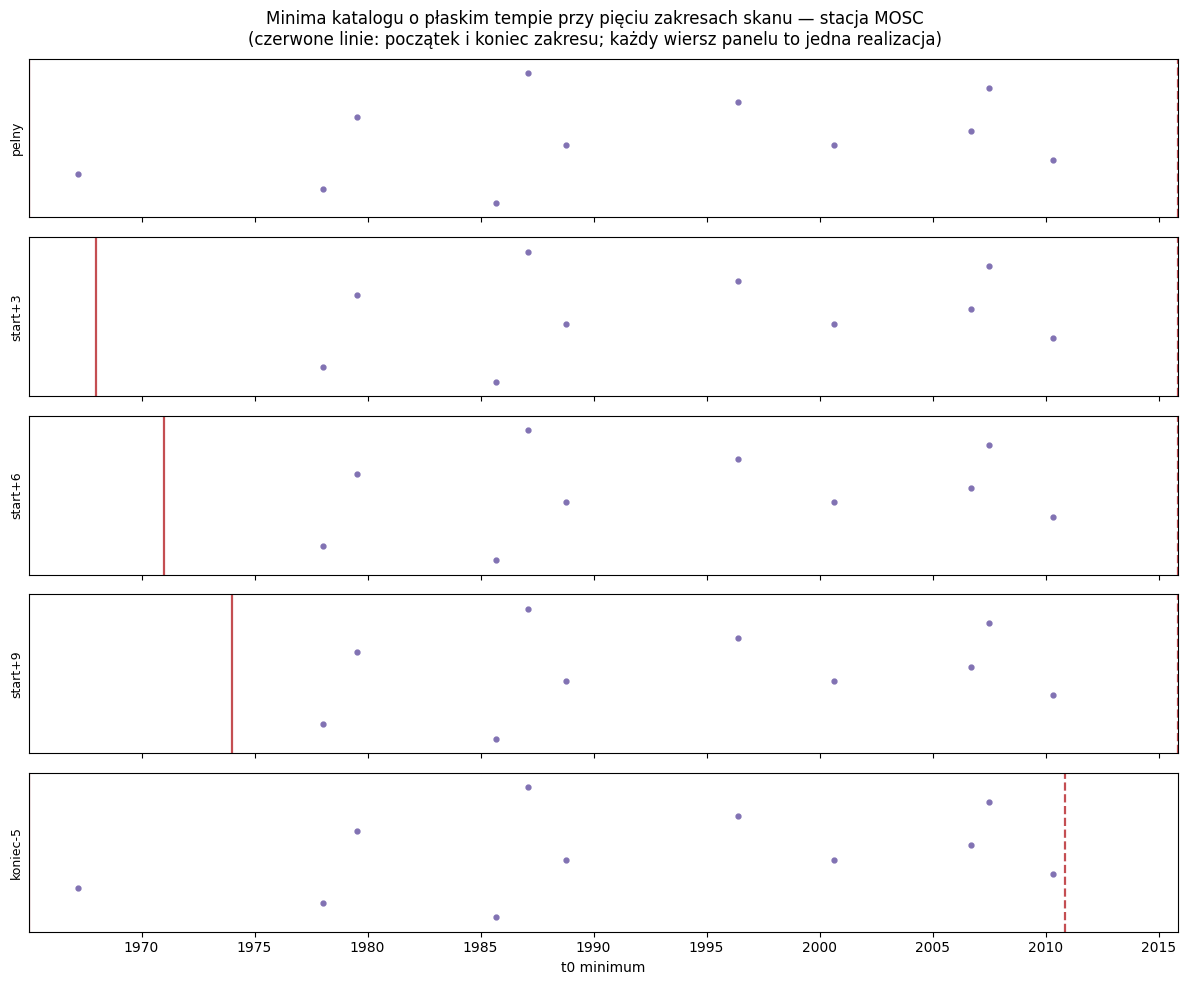

In [8]:
# H1, WYKRES 1 (jedno kodowanie: polozenie znacznika na osi czasu). Gdzie leza
# minima katalogu PLASKIEGO w kazdym z pieciu wariantow zakresu. Pionowe linie
# to poczatki zakresow. Jesli minima ida za pionowymi liniami - H1.
import matplotlib.pyplot as plt

fig, osie = plt.subplots(len(WARIANTY), 1, figsize=(12, 2.0 * len(WARIANTY)), sharex=True)
for ax, (nazwa, _, _) in zip(np.atleast_1d(osie), WARIANTY):
    g = minima[(minima.typ == "plaski") & (minima.wariant == nazwa)]
    ziarna = sorted(minima.loc[minima.typ == "plaski", "ziarno"].unique())
    poz = {z: i for i, z in enumerate(ziarna)}
    ax.plot(g["t0"], [poz[z] for z in g["ziarno"]], "o", color="#8172B3", ms=3.5)
    ax.set_ylim(-1, len(ziarna))
    ax.axvline(siatka[maski[nazwa]].iloc[0], color="#C44E52", lw=1.6)
    ax.axvline(siatka[maski[nazwa]].iloc[-1], color="#C44E52", lw=1.6, ls="--")
    ax.set_xlim(siatka.iloc[0], siatka.iloc[-1])
    ax.set_ylabel(nazwa, fontsize=9)
    ax.set_yticks([])
np.atleast_1d(osie)[-1].set_xlabel("t0 minimum")
fig.suptitle(f"Minima katalogu o płaskim tempie przy pięciu zakresach skanu — "
             f"stacja {STACJA.upper()}\n"
             f"(czerwone linie: początek i koniec zakresu; każdy wiersz panelu "
             f"to jedna realizacja)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/credo_brzeg_1_minima_wg_zakresu_{STACJA}.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_brzeg_1_minima_wg_zakresu_{STACJA}.png")


Zapisano ../results/credo_brzeg_2_odleglosc_od_poczatku_mosc.png


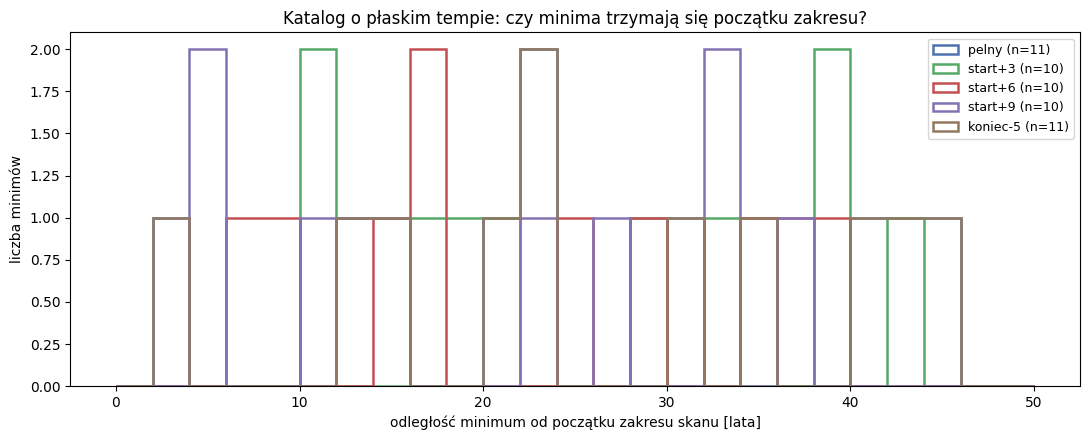

In [9]:
# H1, WYKRES 2 (jedno kodowanie: wysokosc slupka). Ta sama rzecz w innej
# wspolrzednej: odleglosc minimum OD POCZATKU zakresu. Jesli H1 jest prawdziwa,
# wszystkie piec histogramow ma sie pokrywac.
fig, ax = plt.subplots(figsize=(11, 4.5))
kraw = np.arange(0, 51, 2)
for (nazwa, _, _), kolor in zip(WARIANTY, ["#4C72B0", "#55A868", "#C44E52",
                                           "#8172B3", "#937860"]):
    g = minima[(minima.typ == "plaski") & (minima.wariant == nazwa)]
    ax.hist(g["lata_od_poczatku"], bins=kraw, histtype="step", lw=1.8,
            color=kolor, label=f"{nazwa} (n={len(g)})")
ax.set_xlabel("odległość minimum od początku zakresu skanu [lata]")
ax.set_ylabel("liczba minimów")
ax.set_title("Katalog o płaskim tempie: czy minima trzymają się początku zakresu?")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/credo_brzeg_2_odleglosc_od_poczatku_{STACJA}.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_brzeg_2_odleglosc_od_poczatku_{STACJA}.png")


In [ ]:
# POPRAWKA 06.09: mediany licza sie teraz przez nanmedian. Prog higieny
# skanu (statystyka.krzywa, max_jitter_d) zeruje punkty, w ktorych kotwica
# przeniosla okno przez dziure w CR - diagnostyka daje tam p_A = p_B = NaN,
# a zwykla np.median zwracala wtedy NaN dla calej grupy i psula wydruk.
# Merytorycznie nic sie nie zmienia: p_oczek byl i jest 0,5000.
# H2 - DIAGNOSTYKA HIPOTEZY ZEROWEJ. Liczymy p_A, p_B, Np i N_waznych wzdluz
# calej siatki dla trzech katalogow: prawdziwego, jednego plaskiego i jednego
# z trendem. Trzy przebiegi po siatce - w tej samej cenie co trzy krzywe.
SCIEZKA_DIAG = f"{RESULTS_DIR}/credo_brzeg_diagnostyka_{STACJA}.csv"

if not PRZELICZ_OD_NOWA and os.path.exists(SCIEZKA_DIAG):
    diag = pd.read_csv(SCIEZKA_DIAG, parse_dates=["t0"])
    print(f"WCZYTANO {SCIEZKA_DIAG}")
else:
    start = time.time()
    czesci = []
    for nazwa, kat in [("prawdziwy", katalog),
                       ("plaski", surogat_plaski(ZIARNO_BAZOWE)),
                       ("z_trendem", surogat_z_trendem(ZIARNO_BAZOWE + 10000))]:
        Np, Nv, pA, pB = diagnostyka(cr_prep, przygotuj_katalog(kat), siatka_ns)
        czesci.append(pd.DataFrame(dict(typ=nazwa, t0=siatka, Np=Np, Nv=Nv,
                                        pA=pA, pB=pB)))
    diag = pd.concat(czesci, ignore_index=True)
    diag.to_csv(SCIEZKA_DIAG, index=False)
    print(f"Policzono w {(time.time() - start) / 60:.1f} min, zapisano {SCIEZKA_DIAG}")

# p_oczek: jaki udzial zgodnych znakow wychodzi z SAMEJ selekcji koszy, przy
# calkowitym braku zwiazku miedzy A i B.
diag["p_oczek"] = diag["pA"] * diag["pB"] + (1 - diag["pA"]) * (1 - diag["pB"])
# krzywa faktyczna, krzywa przewidziana z samej selekcji, krzywa po poprawce
diag["y"] = -np.log10(binom.pmf(diag["Np"], diag["Nv"], 0.5))
diag["y_przewidziana"] = -np.log10(
    binom.pmf(np.rint(diag["Nv"] * diag["p_oczek"]), diag["Nv"], 0.5))
diag["y_poprawiona"] = -np.log10(binom.pmf(diag["Np"], diag["Nv"], diag["p_oczek"]))

print("\nODCHYLENIA OD 0,5 - to jest cala tresc hipotezy H2")
print(f"{'katalog':12s} {'|p_A-0,5| mediana':>18s} {'|p_B-0,5| mediana':>18s} "
      f"{'p_oczek mediana':>16s} {'p_oczek maks':>13s}")
for typ, g in diag.groupby("typ"):
    print(f"{typ:12s} {np.nanmedian(np.abs(g.pA - 0.5)):18.4f} "
          f"{np.nanmedian(np.abs(g.pB - 0.5)):18.4f} {g.p_oczek.median(skipna=True):16.4f} "
          f"{g.p_oczek.max(skipna=True):13.4f}")
print()
print("Przypomnienie: wsrod WSZYSTKICH koszy okna p_A i p_B wynosza 0,5 z")
print("definicji (normalizacja mediana). Kazde odchylenie wyzej pochodzi")
print("wylacznie z tego, ze czesc koszy odpada z testu - luki w danych CR i")
print("puste kosze sejsmiczne.")


In [11]:
# H2 - ILE Z KRZYWEJ TLUMACZY SAMA SELEKCJA KOSZY, i co zostaje po poprawce.
print("KORELACJA KRZYWEJ FAKTYCZNEJ Z PRZEWIDZIANA Z SAMYCH p_A, p_B")
for typ, g in diag.groupby("typ"):
    ok = (g["y"].notna() & g["y_przewidziana"].notna()).to_numpy()
    r = np.corrcoef(g["y"].to_numpy()[ok], g["y_przewidziana"].to_numpy()[ok])[0, 1]
    print(f"  {typ:12s} r = {r:.3f};  mediana krzywej faktycznej "
          f"{g['y'].median():.2f}, przewidzianej {g['y_przewidziana'].median():.2f}, "
          f"po poprawce {g['y_poprawiona'].median():.2f}")

print("\nPIEC ER KATALOGU PRAWDZIWEGO: glebokosc przed poprawka i po niej")
gp = diag[diag.typ == "prawdziwy"].reset_index(drop=True)
piki, _ = find_peaks(np.nan_to_num(gp["y"].to_numpy(), nan=-1.0),
                     height=PROG_WYSOKOSCI, distance=DISTANCE)
print(f"{'era (t0)':14s} {'glebokosc':>10s} {'z samej selekcji':>17s} "
      f"{'po poprawce':>12s} {'zostaje powyzej progu':>23s}")
tab_ery = []
for p in piki:
    r = gp.iloc[p]
    zostaje = "TAK" if r["y_poprawiona"] >= PROG_WYSOKOSCI else "NIE"
    tab_ery.append(dict(t0=r["t0"], y=r["y"], y_przewidziana=r["y_przewidziana"],
                        y_poprawiona=r["y_poprawiona"], powyzej_progu=zostaje == "TAK"))
    print(f"{str(r['t0'].date()):14s} {r['y']:10.2f} {r['y_przewidziana']:17.2f} "
          f"{r['y_poprawiona']:12.2f} {zostaje:>23s}")
tab_ery = pd.DataFrame(tab_ery, columns=["t0", "y", "y_przewidziana",
                                         "y_poprawiona", "powyzej_progu"])
tab_ery.to_csv(f"{RESULTS_DIR}/credo_brzeg_ery_po_poprawce_{STACJA}.csv", index=False)
print(f"\nZapisano {RESULTS_DIR}/credo_brzeg_ery_po_poprawce_{STACJA}.csv")
print()
print("Jak to czytac: kolumna 'z samej selekcji' mowi, ile -log10(PPDF) wyszloby")
print("w tym punkcie przy ZEROWYM zwiazku CR-EQ, gdyby tylko odpadly te same")
print("kosze. Kolumna 'po poprawce' to ten sam Np testowany przeciw p_oczek")
print("zamiast 0,5 - czyli tyle istotnosci, ile zostaje po odjeciu selekcji.")


KORELACJA KRZYWEJ FAKTYCZNEJ Z PRZEWIDZIANA Z SAMYCH p_A, p_B
  plaski       r = 0.055;  mediana krzywej faktycznej 1.60, przewidzianej 1.51, po poprawce 1.60
  prawdziwy    r = -0.145;  mediana krzywej faktycznej 2.06, przewidzianej 1.51, po poprawce 2.08
  z_trendem    r = 0.047;  mediana krzywej faktycznej 2.17, przewidzianej 1.51, po poprawce 2.20

PIEC ER KATALOGU PRAWDZIWEGO: glebokosc przed poprawka i po niej
era (t0)        glebokosc  z samej selekcji  po poprawce   zostaje powyzej progu
1968-03-24           9.72              1.51         9.72                     TAK
1978-05-24           6.20              1.51         6.20                     TAK
1989-03-03           6.68              1.51         6.68                     TAK
1999-02-18           7.84              1.51         7.84                     TAK
2008-08-08           8.46              1.51         8.46                     TAK

Zapisano ../results/credo_brzeg_ery_po_poprawce_mosc.csv

Jak to czytac: kolumna 'z samej sel

Zapisano ../results/credo_brzeg_3_selekcja_koszy_mosc.png


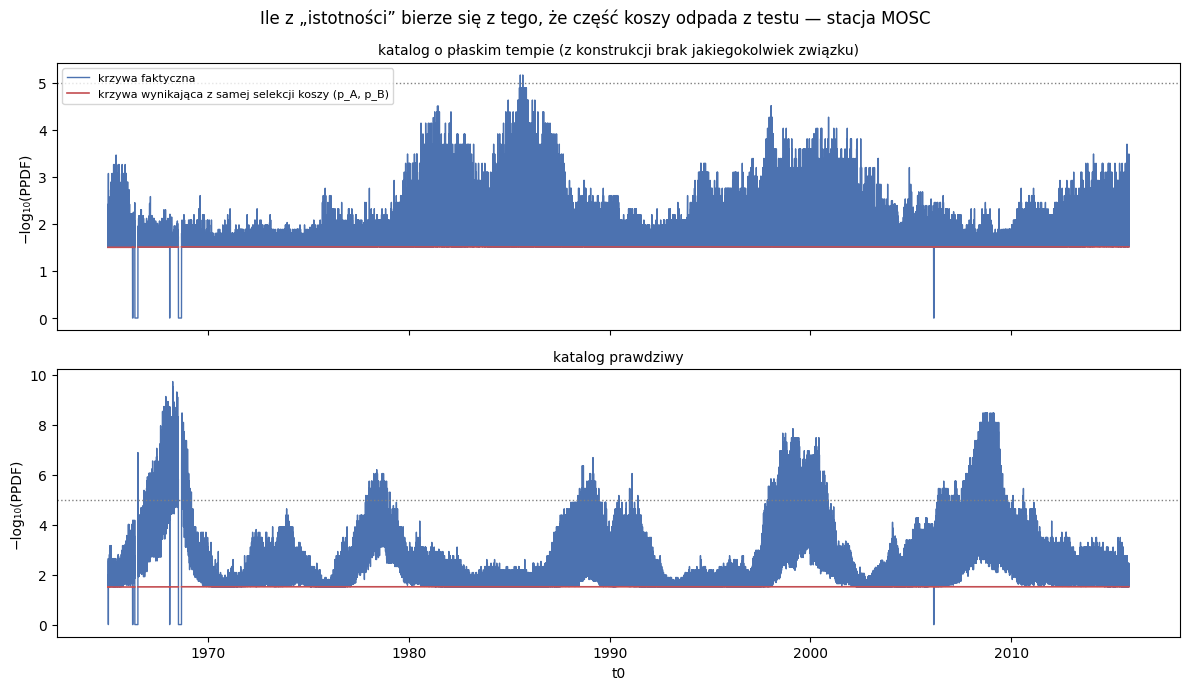

In [12]:
# H2, WYKRES 3 (jedno kodowanie: wysokosc krzywej). Krzywa faktyczna kontra
# krzywa wynikajaca z samej selekcji koszy, dla katalogu PLASKIEGO - czyli tam,
# gdzie zadnego zwiazku nie ma z konstrukcji. Osobny panel: to samo dla
# katalogu prawdziwego.
fig, osie = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, typ, tytul in [(osie[0], "plaski", "katalog o płaskim tempie "
                        "(z konstrukcji brak jakiegokolwiek związku)"),
                       (osie[1], "prawdziwy", "katalog prawdziwy")]:
    g = diag[diag.typ == typ]
    ax.plot(g["t0"], g["y"], color="#4C72B0", lw=1.0, label="krzywa faktyczna")
    ax.plot(g["t0"], g["y_przewidziana"], color="#C44E52", lw=1.2,
            label="krzywa wynikająca z samej selekcji koszy (p_A, p_B)")
    ax.axhline(PROG_WYSOKOSCI, color="gray", ls=":", lw=1)
    ax.set_ylabel("−log₁₀(PPDF)")
    ax.set_title(tytul, fontsize=10)
osie[0].legend(loc="upper left", fontsize=8)
osie[1].set_xlabel("t0")
fig.suptitle(f"Ile z „istotności” bierze się z tego, że część koszy odpada "
             f"z testu — stacja {STACJA.upper()}")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/credo_brzeg_3_selekcja_koszy_{STACJA}.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_brzeg_3_selekcja_koszy_{STACJA}.png")


Zapisano ../results/credo_brzeg_4_skladniki_mosc.png


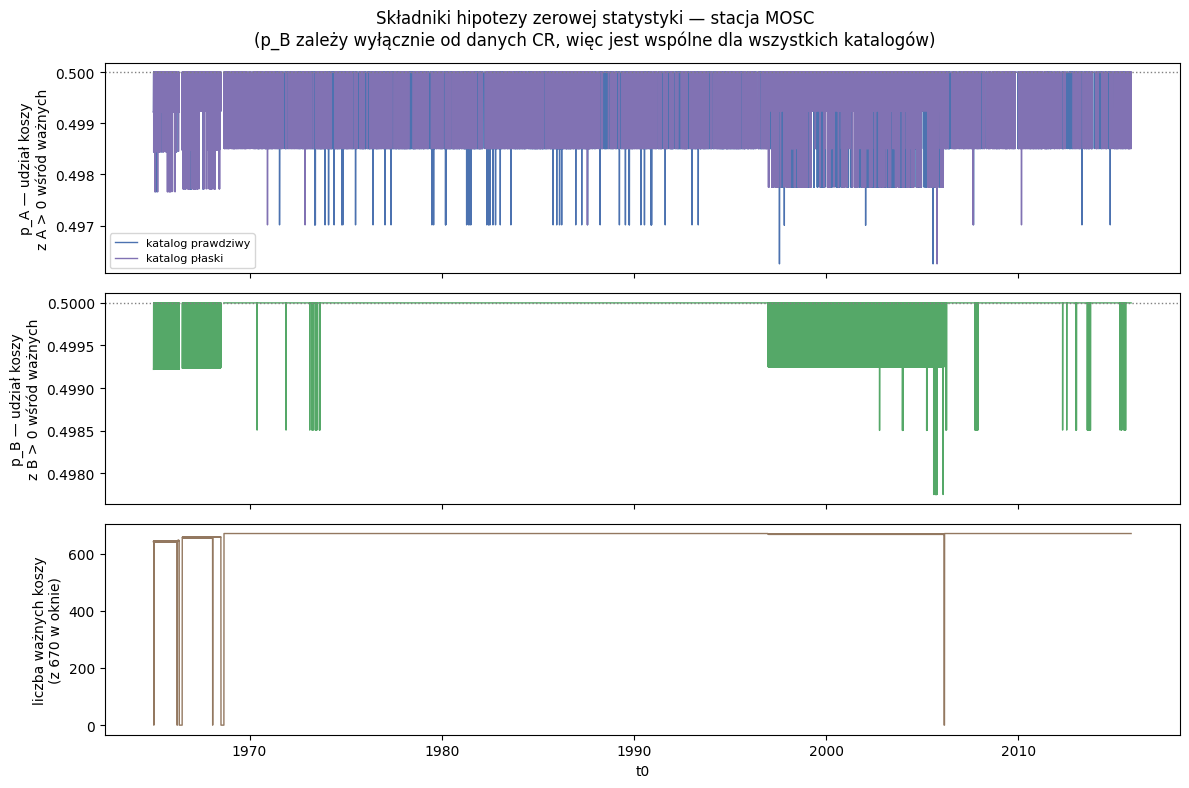

In [13]:
# H2, WYKRES 4 (jedno kodowanie: wysokosc krzywej). Same skladniki: p_A, p_B i
# liczba waznych koszy wzdluz siatki. Osobny wykres, bo to inne wielkosci niz
# PPDF i mieszanie ich na jednej osi nic nie da.
gp_pl = diag[diag.typ == "plaski"]
gp_pr = diag[diag.typ == "prawdziwy"]
fig, osie = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
osie[0].plot(gp_pr["t0"], gp_pr["pA"], color="#4C72B0", lw=1.0, label="katalog prawdziwy")
osie[0].plot(gp_pl["t0"], gp_pl["pA"], color="#8172B3", lw=1.0, label="katalog płaski")
osie[0].axhline(0.5, color="gray", ls=":", lw=1)
osie[0].set_ylabel("p_A — udział koszy\nz A > 0 wśród ważnych")
osie[0].legend(fontsize=8)
osie[1].plot(gp_pr["t0"], gp_pr["pB"], color="#55A868", lw=1.0)
osie[1].axhline(0.5, color="gray", ls=":", lw=1)
osie[1].set_ylabel("p_B — udział koszy\nz B > 0 wśród ważnych")
osie[2].plot(gp_pr["t0"], gp_pr["Nv"], color="#937860", lw=1.0)
osie[2].set_ylabel("liczba ważnych koszy\n(z 670 w oknie)")
osie[2].set_xlabel("t0")
fig.suptitle(f"Składniki hipotezy zerowej statystyki — stacja {STACJA.upper()}\n"
             f"(p_B zależy wyłącznie od danych CR, więc jest wspólne dla "
             f"wszystkich katalogów)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/credo_brzeg_4_skladniki_{STACJA}.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_brzeg_4_skladniki_{STACJA}.png")


In [ ]:
# POPRAWKA 06.09: mediany licza sie teraz przez nanmedian. Prog higieny
# skanu (statystyka.krzywa, max_jitter_d) zeruje punkty, w ktorych kotwica
# przeniosla okno przez dziure w CR - diagnostyka daje tam p_A = p_B = NaN,
# a zwykla np.median zwracala wtedy NaN dla calej grupy i psula wydruk.
# Merytorycznie nic sie nie zmienia: p_oczek byl i jest 0,5000.
# PODSUMOWANIE, czytane wedlug regul ustalonych w komorce 0 PRZED liczeniem.
print("=" * 78)
print("SKAD BIORA SIE MINIMA BEZ SYGNALU - PODSUMOWANIE")
print("=" * 78)
print()
print("H1 - EFEKT BRZEGU ZAKRESU SKANU")
print(f"  Udzial przesuniecia mediany daty pierwszego minimum w przesunieciu")
print(f"  zakresu (srednio po wariantach): {udzial_sredni:.2f}")
if np.isnan(udzial_sredni):
    print("  ODCZYT: nie da sie ocenic - w wariantach przycietych nie ma minimow.")
elif udzial_sredni >= 2 / 3:
    print("  ODCZYT: H1 POTWIERDZONA. Minima katalogu plaskiego ida za poczatkiem")
    print("  zakresu skanu, a nie za kalendarzem. Sa artefaktem zakresu, nie danych.")
    print("  KONSEKWENCJA: era 1968 wypada z materialu dowodowego calego repo -")
    print("  takze z wpisow z 26.08 i 31.08, gdzie byla najglebszym minimum.")
elif udzial_sredni <= 1 / 3:
    print("  ODCZYT: H1 ODRZUCONA. Minima stoja w tych samych datach niezaleznie od")
    print("  zakresu, wiec produkuja je wczesne dane CR (lata 1965-1975), a nie")
    print("  brzeg skanu. Wtedy trzeba obejrzec jakosc danych stacji z tego okresu.")
else:
    print("  ODCZYT: WYNIK POSREDNI - obie przyczyny dzialaja naraz. Do zapisania")
    print("  w dzienniku jako taki, bez wybierania jednej z nich.")
print()

print("H2 - ZLAMANA HIPOTEZA ZEROWA STATYSTYKI")
for typ in ("plaski", "prawdziwy"):
    g = diag[diag.typ == typ]
    ok = (g["y"].notna() & g["y_przewidziana"].notna()).to_numpy()
    r = float(np.corrcoef(g["y"].to_numpy()[ok],
                          g["y_przewidziana"].to_numpy()[ok])[0, 1])
    print(f"  {typ:10s}: |p_A-0,5| mediana {np.nanmedian(np.abs(g.pA - 0.5)):.4f}, "
          f"|p_B-0,5| mediana {np.nanmedian(np.abs(g.pB - 0.5)):.4f}, "
          f"korelacja z krzywa przewidziana r = {r:.3f}")
_mpl = ((diag.typ == "plaski") & diag.y.notna() & diag.y_przewidziana.notna())
r_plaski = float(np.corrcoef(diag.loc[_mpl, "y"], diag.loc[_mpl, "y_przewidziana"])[0, 1])
spadlo = int((~tab_ery["powyzej_progu"]).sum())
male_odchylenia = bool((np.abs(diag.pA - 0.5) < 0.01).all()
                       and (np.abs(diag.pB - 0.5) < 0.01).all())
if male_odchylenia:
    print("  ODCZYT: H2 ODRZUCONA. p_A i p_B trzymaja sie 0,5 z dokladnoscia do")
    print("  0,01 na calej siatce, wiec selekcja koszy nie moze niczego tlumaczyc.")
    print("  Hipoteza zerowa p = 0,5 jest w tym miejscu poprawna i zarzut upada.")
elif r_plaski >= 0.5 or spadlo > 0:
    print("  ODCZYT: H2 POTWIERDZONA.")
    if r_plaski >= 0.5:
        print(f"  Krzywa katalogu plaskiego jest odtwarzana z samej selekcji koszy")
        print(f"  (r = {r_plaski:.3f}) - czyli 'istotnosc' powstaje bez zadnego zwiazku.")
    if spadlo > 0:
        print(f"  Po poprawieniu hipotezy zerowej {spadlo} z {len(tab_ery)} er katalogu")
        print(f"  prawdziwego spada ponizej progu {PROG_WYSOKOSCI}.")
    print("  KONSEKWENCJA: to jest zarzut do samego przepisu z sekcji 4, niezalezny")
    print("  od wszystkiego, co pokazalismy o katalogu USGS. Przed zacytowaniem")
    print("  wymaga sprawdzenia na drugiej stacji.")
else:
    print("  ODCZYT: H2 NIEROZSTRZYGNIETA. Odchylenia p_A i p_B od 0,5 sa niezerowe,")
    print("  ale nie tlumacza ksztaltu krzywej i nie zbijaja zadnej ery ponizej")
    print("  progu. Efekt istnieje, lecz jest drugorzedny.")
print()
print("OGRANICZENIE OBU CZESCI: jedna stacja (" + STACJA.upper() + ") i jeden")
print("katalog. Powtorzenie na hrms kosztuje tyle samo - wystarczy zmienic STACJA")
print("w komorce 0.")
